In [ ]:
1604,788
2765,1732

In [2]:
import os
from PIL import Image

# input and output folders
input_folder = r"F:\strwaberry images\back row upated with text"
output_base = r"F:\strwaberry images\back row upated with text\Cropped_Images"

# cropping coordinates: (x1, y1, x2, y2)
crops = {
    # "down_1": (15, 423, 722,928),
    # "down_2": (909,268, 1503,884),
    "down_3": (1604,788,2765,1732)
    # "down_4": (2405, 418, 2961,911),
    # "down_5": (3237,431, 3809, 867),
}

# create output folders
for folder in crops.keys():
    os.makedirs(os.path.join(output_base, folder), exist_ok=True)

# process images
for img_name in os.listdir(input_folder):
    if img_name.lower().endswith((".jpg", ".jpeg", ".png")):
        img_path = os.path.join(input_folder, img_name)
        image = Image.open(img_path)

        for folder_name, (x1, y1, x2, y2) in crops.items():
            cropped = image.crop((x1, y1, x2, y2))

            save_path = os.path.join(output_base, folder_name, img_name)
            cropped.save(save_path)

print("Cropping completed")

Cropping completed


In [6]:
import cv2
import numpy as np

# -----------------------------
# Step 1: Load images
# -----------------------------
ref_img = cv2.imread(r"F:\strwaberry images\back row upated with text\Cropped_Images\down_3\citra_2025-12-15_154501.jpg")
unk_img = cv2.imread(r"F:\strwaberry images\back row upated with text\Cropped_Images\down_3\citra_2025-12-16_063001.jpg")

# Convert to float for safe multiplication
ref_img = ref_img.astype(np.float32)
unk_img = unk_img.astype(np.float32)

# -----------------------------
# Step 2: Manually define duct tape ROI
# (x1,y1,x2,y2) change based on image
# -----------------------------
ref_roi = ref_img[0:1158, 866:943]   # reference duct tape
unk_roi = unk_img[0:1158, 866:943]   # unknown duct tape

# -----------------------------
# Step 3: Compute mean RGB
# -----------------------------
ref_mean = np.mean(ref_roi.reshape(-1,3), axis=0)
unk_mean = np.mean(unk_roi.reshape(-1,3), axis=0)

print("Reference RGB:", ref_mean)
print("Unknown RGB:", unk_mean)

# -----------------------------
# Step 4: Compute scaling factors
# -----------------------------
scale = ref_mean / unk_mean

print("Scale factors:", scale)

# -----------------------------
# Step 5: Apply normalization
# -----------------------------
normalized = unk_img * scale

# Clip values
normalized = np.clip(normalized, 0, 255).astype(np.uint8)

# -----------------------------
# Step 6: Save result
# -----------------------------
cv2.imwrite("normalized_image.jpg", normalized)

print("Normalization completed")

Reference RGB: [64.895454 72.75579  70.9636  ]
Unknown RGB: [24.892458 21.274378 25.08037 ]
Scale factors: [2.6070328 3.4198787 2.829448 ]
Normalization completed


In [7]:
import cv2
import numpy as np
import os
from tqdm import tqdm

# -----------------------------
# Paths
# -----------------------------
reference_path = r"F:\strwaberry images\back row upated with text\Cropped_Images\down_3\citra_2025-12-15_154501.jpg"
folder_path = r"F:\strwaberry images\back row upated with text\Cropped_Images\down_3"
output_folder = os.path.join(folder_path, r"F:\strwaberry images\back row upated with text\Cropped_Images\down_3\down3_normalized")

os.makedirs(output_folder, exist_ok=True)

# -----------------------------
# ROI (duct tape)
# -----------------------------
y1, y2 = 0, 1158
x1, x2 = 866, 943

# -----------------------------
# Load reference image
# -----------------------------
ref_img = cv2.imread(reference_path).astype(np.float32)

ref_roi = ref_img[y1:y2, x1:x2]

# Average RGB of reference duct tape
ref_mean = np.mean(ref_roi.reshape(-1,3), axis=0)

print("Reference duct tape RGB:", ref_mean)

# -----------------------------
# Process all images
# -----------------------------
for file in tqdm(os.listdir(folder_path)):

    if not file.lower().endswith((".jpg",".png",".jpeg")):
        continue

    img_path = os.path.join(folder_path, file)

    img = cv2.imread(img_path).astype(np.float32)

    # Extract duct tape ROI
    roi = img[y1:y2, x1:x2]

    unk_mean = np.mean(roi.reshape(-1,3), axis=0)

    # Scaling factors
    scale = ref_mean / unk_mean

    # Apply normalization
    normalized = img * scale

    normalized = np.clip(normalized, 0, 255).astype(np.uint8)

    # Save image
    save_path = os.path.join(output_folder, file)
    cv2.imwrite(save_path, normalized)

print("Normalization finished")

Reference duct tape RGB: [64.895454 72.75579  70.9636  ]


100%|██████████| 1558/1558 [00:57<00:00, 27.12it/s]

Normalization finished


In [13]:
## cropping of strawberry 

import cv2
import os
from tqdm import tqdm

# -----------------------------
# Input and Output folders
# -----------------------------
input_folder = r"F:\strwaberry images\back row upated with text\Cropped_Images\down_3\strawberry"
output_folder = r"F:\strwaberry images\back row upated with text\Cropped_Images\down_3\strawberry_cropped"

os.makedirs(output_folder, exist_ok=True)

# -----------------------------
# ROI Coordinates
# -----------------------------
y1, y2 = 748,940
x1, x2 = 256,581

# -----------------------------
# Process all images
# -----------------------------
for file in tqdm(os.listdir(input_folder)):

    if not file.lower().endswith((".jpg",".jpeg",".png")):
        continue

    path = os.path.join(input_folder, file)

    img = cv2.imread(path)

    if img is None:
        continue

    # Crop ROI
    crop = img[y1:y2, x1:x2]

    # Save cropped image
    save_path = os.path.join(output_folder, file)
    cv2.imwrite(save_path, crop)

print("Cropping completed")

100%|██████████| 160/160 [00:00<00:00, 198.63it/s]

Cropping completed


In [15]:
## cropping of strawberry 

import cv2
import os
from tqdm import tqdm

# -----------------------------
# Input and Output folders
# -----------------------------
input_folder = r"F:\strwaberry images\back row upated with text\Cropped_Images\down_3\strawberry_2"
output_folder = r"F:\strwaberry images\back row upated with text\Cropped_Images\down_3\strawberry_cropped_new"

os.makedirs(output_folder, exist_ok=True)

# -----------------------------
# ROI Coordinates
# -----------------------------
y1, y2 = 702,939
x1, x2 = 89,349

# -----------------------------
# Process all images
# -----------------------------
for file in tqdm(os.listdir(input_folder)):

    if not file.lower().endswith((".jpg",".jpeg",".png")):
        continue

    path = os.path.join(input_folder, file)

    img = cv2.imread(path)

    if img is None:
        continue

    # Crop ROI
    crop = img[y1:y2, x1:x2]

    # Save cropped image
    save_path = os.path.join(output_folder, file)
    cv2.imwrite(save_path, crop)

print("Cropping completed")

100%|██████████| 19/19 [00:00<00:00, 64.86it/s]

Cropping completed


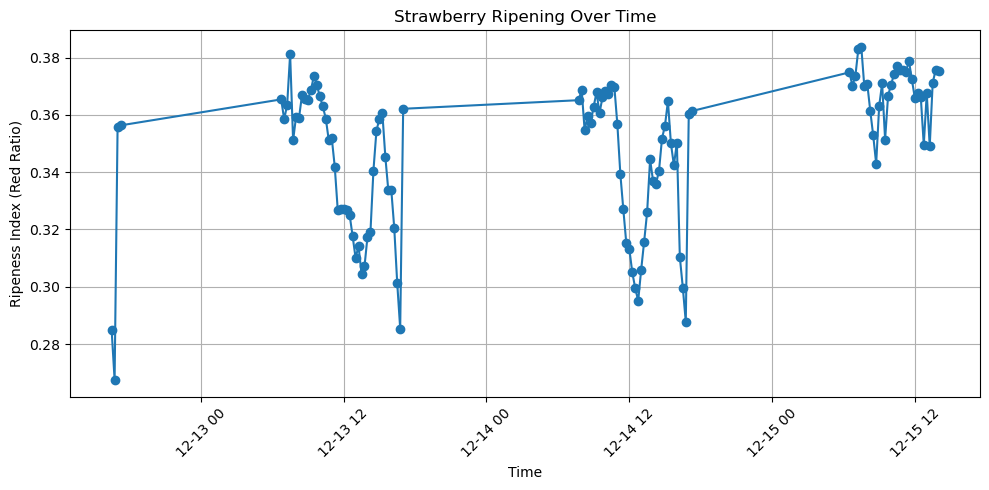

In [22]:
import cv2
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Folder containing cropped strawberries
folder = r"F:\strwaberry images\back row upated with text\Cropped_Images\down_3\strawberry_cropped"

data = []

for file in os.listdir(folder):

    if not file.endswith(".jpg"):
        continue

    path = os.path.join(folder, file)

    img = cv2.imread(path)

    # Convert to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Flatten pixels
    pixels = img.reshape(-1,3)

    # Mean color
    mean_r = np.mean(pixels[:,0])
    mean_g = np.mean(pixels[:,1])
    mean_b = np.mean(pixels[:,2])

    # Ripeness index
    red_ratio = mean_r / (mean_r + mean_g + mean_b)

    # Extract timestamp from filename
    name = file.replace(".jpg","")
    timestamp = name.split("_",1)[1]

    time = datetime.strptime(timestamp,"%Y-%m-%d_%H%M%S")

    data.append([time,mean_r,mean_g,mean_b,red_ratio])

# Create dataframe
df = pd.DataFrame(data,columns=["time","R","G","B","ripeness"])

# Sort by time
df = df.sort_values("time")

# Plot
plt.figure(figsize=(10,5))

plt.plot(df["time"],df["ripeness"],marker="o")

plt.title("Strawberry Ripening Over Time")
plt.xlabel("Time")
plt.ylabel("Ripeness Index (Red Ratio)")
plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()
plt.show()

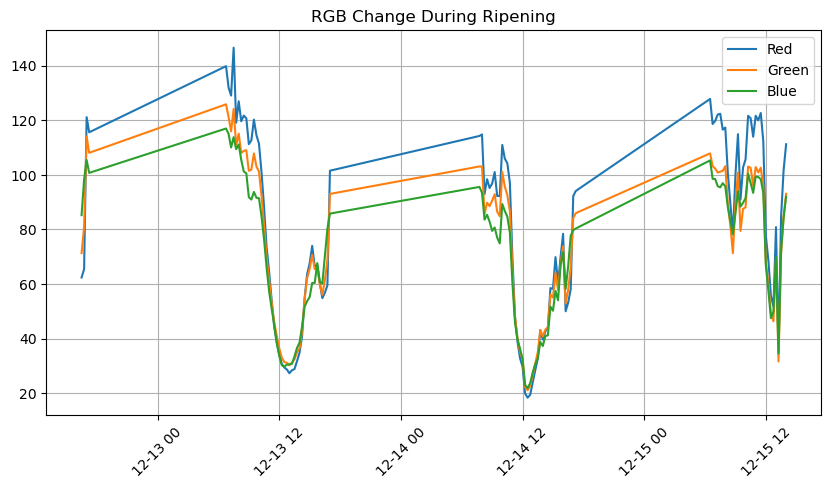

In [17]:
plt.figure(figsize=(10,5))

plt.plot(df["time"],df["R"],label="Red")
plt.plot(df["time"],df["G"],label="Green")
plt.plot(df["time"],df["B"],label="Blue")

plt.legend()
plt.title("RGB Change During Ripening")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [27]:
import cv2
import numpy as np
import os
import pandas as pd
import plotly.express as px
from datetime import datetime

# Folder containing cropped strawberries
folder = r"F:\strwaberry images\back row upated with text\Cropped_Images\down_3\strawberry_cropped"

data = []

for file in os.listdir(folder):

    if not file.endswith(".jpg"):
        continue

    path = os.path.join(folder, file)

    img = cv2.imread(path)

    # Convert BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Flatten pixels
    pixels = img.reshape(-1,3)

    # Mean RGB values
    mean_r = np.mean(pixels[:,0])
    mean_g = np.mean(pixels[:,1])
    mean_b = np.mean(pixels[:,2])

    # Ripeness index
    red_ratio = mean_r / (mean_r + mean_g + mean_b)

    # Extract timestamp
    name = file.replace(".jpg","")
    timestamp = name.split("_",1)[1]

    time = datetime.strptime(timestamp,"%Y-%m-%d_%H%M%S")

    data.append({
        "time": time,
        "R": mean_r,
        "G": mean_g,
        "B": mean_b,
        "ripeness": red_ratio,
        "image": path
    })

# Convert to dataframe
df = pd.DataFrame(data)

# Sort by time
df = df.sort_values("time")

# Plotly interactive graph
fig = px.scatter(
    df,
    x="time",
    y="ripeness",
    hover_data=["R","G","B","image"],
    title="Strawberry Ripening Over Time",
)

fig.update_traces(mode="lines+markers")

fig.show()

In [18]:
import cv2
import numpy as np
import os

input_folder = r"F:\strwaberry images\back row upated with text\Cropped_Images\down_3\strawberry_cropped"
output_folder = r"F:\strwaberry images\back row upated with text\Cropped_Images\down_3\fruit_only"

os.makedirs(output_folder, exist_ok=True)

for file in os.listdir(input_folder):

    if not file.lower().endswith(".jpg"):
        continue

    path = os.path.join(input_folder, file)

    img = cv2.imread(path)

    # Convert to HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Strawberry color range (white -> pink -> red)
    lower = np.array([0, 30, 40])
    upper = np.array([180, 255, 255])

    mask = cv2.inRange(hsv, lower, upper)

    # Remove noise
    kernel = np.ones((5,5),np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    # Apply mask
    result = cv2.bitwise_and(img, img, mask=mask)

    save_path = os.path.join(output_folder, file)

    cv2.imwrite(save_path, result)

print("Background removal completed")

Background removal completed


In [28]:
import cv2
import numpy as np

img = cv2.imread(r"F:\strwaberry images\back row upated with text\citra_2025-12-13_123001.jpg")

b,g,r = cv2.split(img)

exg = 2*g - r - b

mask = exg > 30
mask = mask.astype(np.uint8)*255

result = cv2.bitwise_and(img,img,mask=mask)

cv2.imwrite("plants_only.png",result)

True